# Ngày 3 — Tracking: cho model chạy cùng clip bạn vừa gán nhãn

Notebook này làm đúng ba việc:

1. Chạy **YOLO26 + ByteTrack** trên `clip_01` — chính clip bạn vừa gán nhãn tay.
2. Xuất kết quả của model ra **cùng định dạng MOT 1.1** với nhãn của bạn.
3. Chấm **ba chiều** bằng cùng một bộ công cụ: bạn vs gold, model vs gold, model vs bạn.

> **Chỉ chạy notebook này SAU KHI đã qua cổng annotation.**
> Xem kết quả của model trước khi tự gán xong rất dễ khiến bạn tin nhầm vào model.
> Model không phải đáp án — nó chỉ chỉ chỗ đáng ngờ.


## 1. Lấy repo và cài thư viện

**Cách 1 (khuyến nghị)** — clone fork của bạn. Sửa `REPO_URL` thành fork của chính bạn,
vì notebook cần đọc nhãn bạn đã commit trong `annotations/`.

**Cách 2** — nếu chưa push nhãn lên GitHub, clone xong rồi upload tay `gt.txt` vào
`annotations/clip_01/` bằng bảng Files bên trái Colab.


In [1]:
REPO_URL = "https://github.com/<tai-khoan-cua-ban>/<ten-repo>.git"  # <-- SỬA DÒNG NÀY
LAB_DIR  = "Day3-Lab"

import os, sys, subprocess, json
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

def find_root(start: Path):
    """Tìm thư mục Day3-Lab bằng mốc data/clips/clip_01/seqinfo.ini."""
    for base in [start, *start.parents]:
        for candidate in (base, base / LAB_DIR):
            if (candidate / "data" / "clips" / "clip_01" / "seqinfo.ini").exists():
                return candidate.resolve()
    return None

ROOT = find_root(Path.cwd())
if ROOT is None and IN_COLAB and not REPO_URL.startswith("https://github.com/<"):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    ROOT = find_root(Path.cwd())

assert ROOT is not None, (
    "Chưa thấy Day3-Lab. Sửa REPO_URL ở trên rồi chạy lại, "
    "hoặc upload thư mục Day3-Lab lên Colab."
)
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "tools"))
print("ROOT =", ROOT)


ROOT = /content/K4-DAY03-DoanVanThang-2A202602327


In [2]:
%pip install --quiet ultralytics
import ultralytics
print("ultralytics", ultralytics.__version__)


ultralytics 8.4.153


## 2. Kiểm tra dữ liệu trước khi chạy

Cell này dừng sớm nếu thiếu frame hoặc thiếu nhãn — rẻ hơn nhiều so với chạy tracker
190 frame rồi mới phát hiện đường dẫn sai.


In [3]:
from motlib import parse_mot, by_track, by_frame

CLIP      = ROOT / "data" / "clips" / "clip_01"
MY_LABELS = ROOT / "annotations" / "clip_01" / "gt.txt"
GOLD      = ROOT / "gold" / "clip_01" / "gt.txt"
OUT       = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

frames = sorted((CLIP / "img1").glob("*.jpg"))
seqinfo = dict(
    line.split("=", 1)
    for line in (CLIP / "seqinfo.ini").read_text().splitlines()
    if "=" in line and not line.startswith("[")
)
print("clip_01: {} frame · {}x{} @ {} fps".format(
    len(frames), seqinfo["imWidth"], seqinfo["imHeight"], seqinfo["frameRate"]))
assert len(frames) == int(seqinfo["seqLength"]), "Thiếu frame — kiểm tra lại thư mục img1/"

HAS_MINE = MY_LABELS.exists()
HAS_GOLD = GOLD.exists()

if HAS_MINE:
    mine = parse_mot(MY_LABELS)
    print("nhãn của bạn : {} bbox · {} track".format(len(mine), len(by_track(mine))))
else:
    print("CHƯA CÓ nhãn của bạn tại {} — upload gt.txt vào đó rồi chạy lại.".format(MY_LABELS))

if HAS_GOLD:
    gold = parse_mot(GOLD)
    print("gold         : {} bbox · {} track".format(len(gold), len(by_track(gold))))
else:
    print("CHƯA CÓ gold tại {}.".format(GOLD))
    print("Giảng viên phát ở mốc 2:35. Chưa có gold thì notebook vẫn chạy,")
    print("chỉ bỏ qua hai phép so cần gold.")


clip_01: 190 frame · 960x540 @ 12.5 fps
nhãn của bạn : 555 bbox · 8 track
gold         : 573 bbox · 8 track


## 3. Tracking-by-detection

Nhắc lại slide: tracker **không** nhìn cả video một lượt. Nó làm hai bước, lặp lại từng frame:

1. **Detector** (YOLO) tìm bbox trên frame hiện tại — đúng bài toán Ngày 2, không có ký ức gì.
2. **Association** (ByteTrack) nối bbox mới với track cũ, dựa trên vị trí Kalman dự đoán và
   độ chồng lấp IoU. Đây là bước sinh ra `track_id`.

ByteTrack khác các tracker cũ đúng một chỗ: nó **không vứt bbox điểm thấp**. Vòng 1 khớp bbox
điểm cao; vòng 2 lấy những bbox điểm thấp còn lại và thử khớp tiếp — vì một chiếc xe bị che
một phần vẫn là xe thật, chỉ là detector kém tự tin hơn.

Hai tham số quan trọng trong cell dưới:

- `persist=True` — giữ trạng thái tracker giữa các frame. **Thiếu nó thì mỗi frame là một clip
  mới** và `track_id` bị đánh lại từ đầu, kết quả thành vô nghĩa.
- `classes=[2, 5, 7]` — chỉ lấy `car`, `bus`, `truck` của COCO. Gold chỉ gán xe bốn bánh, nên
  nếu để model bắt cả `motorcycle` (class 3) và người thì mọi bbox đó đều thành FP.


In [4]:
import inspect
import run_tracker

# Đọc luôn mã nguồn của vòng lặp tracking — chỉ khoảng 20 dòng.
print(inspect.getsource(run_tracker.track_clip))


def track_clip(clip: Path, model_name: str, tracker: str, conf: float, iou: float,
               imgsz: int, classes: list[int], device: str | None = None,
               verbose: bool = True) -> list[tuple[int, int, float, float, float, float, float]]:
    """Trả về list (frame, track_id, x, y, w, h, conf) với frame đánh số từ 1."""
    from ultralytics import YOLO

    images = sorted((clip / "img1").glob("*.jpg"))
    if not images:
        raise SystemExit(f"Không thấy ảnh trong {clip / 'img1'}")

    model = YOLO(model_name)
    rows: list[tuple[int, int, float, float, float, float, float]] = []

    for index, image_path in enumerate(images, start=1):
        # persist=True giữ trạng thái tracker giữa các frame — thiếu nó thì mỗi
        # frame là một clip mới và track_id bị đánh lại từ đầu.
        results = model.track(
            source=str(image_path), persist=True, tracker=tracker,
            conf=conf, iou=iou, imgsz=imgsz, classes=classes,
            device=device, ve

In [5]:
import torch

DEVICE  = "0" if torch.cuda.is_available() else "cpu"
MODEL   = "yolo26n.pt"      # thử yolo26s.pt nếu muốn model to hơn
TRACKER = "bytetrack.yaml"  # hoặc botsort.yaml
CONF    = 0.25

print("Chạy trên {}. Trên CPU mất vài phút, trên GPU khoảng 20 giây.".format(DEVICE))

rows = run_tracker.track_clip(
    clip=CLIP, model_name=MODEL, tracker=TRACKER,
    conf=CONF, iou=0.7, imgsz=960, classes=[2, 5, 7], device=DEVICE,
)

MODEL_OUT = OUT / "model_clip_01.txt"
run_tracker.write_mot(rows, MODEL_OUT)

model_dets = parse_mot(MODEL_OUT)
print("\nModel: {} bbox · {} track -> {}".format(
    len(model_dets), len(by_track(model_dets)), MODEL_OUT))
print("3 dòng đầu:")
print("\n".join(MODEL_OUT.read_text().splitlines()[:3]))


Chạy trên 0. Trên CPU mất vài phút, trên GPU khoảng 20 giây.
  frame 25/190 · 62 bbox tích luỹ
  frame 50/190 · 107 bbox tích luỹ
  frame 75/190 · 171 bbox tích luỹ
  frame 100/190 · 236 bbox tích luỹ
  frame 125/190 · 366 bbox tích luỹ
  frame 150/190 · 492 bbox tích luỹ
  frame 175/190 · 575 bbox tích luỹ

Model: 607 bbox · 16 track -> outputs/model_clip_01.txt
3 dòng đầu:
1,1,121.18,336.09,136.19,55.69,0.8704,-1,-1,-1
1,2,733.60,268.21,72.66,36.87,0.8041,-1,-1,-1
1,3,223.87,251.49,81.68,40.59,0.6422,-1,-1,-1


## 4. Chấm ba chiều

Cùng một script `tools/evaluate_tracking.py`, ba phép so, ba câu hỏi khác nhau:

| So sánh | Trả lời câu hỏi |
| --- | --- |
| bạn vs gold | nhãn tay của bạn tốt đến đâu |
| model vs gold | model giỏi đến đâu **trên clip này** |
| model vs bạn | chỗ nào bạn và model không đồng ý — đáng soi nhất |


In [6]:
def evaluate(pred, gt, mode, out_json, pred_label, gt_label):
    """Gọi đúng script bạn đã chạy ở terminal, để số liệu không lệch nhau."""
    result = subprocess.run(
        [sys.executable, str(ROOT / "tools" / "evaluate_tracking.py"),
         "--pred", str(pred), "--gt", str(gt),
         "--seqinfo", str(CLIP / "seqinfo.ini"),
         "--mode", mode, "--output", str(out_json),
         "--pred-label", pred_label, "--gt-label", gt_label],
        capture_output=True, text=True,
    )
    print(result.stdout or result.stderr)
    return json.loads(Path(out_json).read_text()) if Path(out_json).exists() else None

results = {}

if HAS_MINE and HAS_GOLD:
    results["ban_vs_gold"] = evaluate(
        MY_LABELS, GOLD, "annotation", OUT / "eval_vs_gold.json",
        "nhãn của bạn", "gold clip_01")
else:
    print("Bỏ qua: cần cả nhãn của bạn và gold.")


  nhãn của bạn  vs  gold clip_01
  clip: clip_01 · 190 frame · IoU ngưỡng 0.5
  HOTA 0.741   = sqrt(DetA x AssA)   -- điểm tổng của tracking
    DetA 0.717  tìm đúng vật thể chưa (giống bài toán Ngày 2)
    AssA 0.771  giữ đúng ID chưa      (phần riêng của tracking)
    LocA 0.818  bbox khít đến đâu
--------------------------------------------------------------------------
  IDF1 0.954   MOTA 0.909   MOTP 0.789
  FP 17  FN 35  ID switch 0   |  bbox gold 573  bbox của bạn 555  |  track gold 8  track của bạn 8
  CỔNG QUA BÀI
    [ĐẠT ] IDF1  0.954  (cần >= 0.80)
    [ĐẠT ] MOTA  0.909  (cần >= 0.75)
    [ĐẠT ] MOTP  0.789  (cần >= 0.70)
  => ĐẠT — sang bước chạy model

  4. BBOX TRÔI — bbox lệch khỏi vật thể, thường ở giữa hai keyframe  (14)
    - frame 90: track gold 5 chỉ còn IoU 0.51 -> thêm keyframe quanh đây
    - frame 96: track gold 5 chỉ còn IoU 0.52 -> thêm keyframe quanh đây
    - frame 89: track gold 5 chỉ còn IoU 0.54 -> thêm keyframe quanh đây
    - frame 117: track gold 6 c

In [7]:
if HAS_GOLD:
    results["model_vs_gold"] = evaluate(
        MODEL_OUT, GOLD, "model", OUT / "eval_model_vs_gold.json",
        MODEL + " + " + TRACKER, "gold clip_01")
else:
    print("Bỏ qua: chưa có gold.")


  yolo26n.pt + bytetrack.yaml  vs  gold clip_01
  clip: clip_01 · 190 frame · IoU ngưỡng 0.5
  HOTA 0.709   = sqrt(DetA x AssA)   -- điểm tổng của tracking
    DetA 0.649  tìm đúng vật thể chưa (giống bài toán Ngày 2)
    AssA 0.776  giữ đúng ID chưa      (phần riêng của tracking)
    LocA 0.846  bbox khít đến đâu
--------------------------------------------------------------------------
  IDF1 0.875   MOTA 0.749   MOTP 0.823
  FP 88  FN 54  ID switch 2   |  bbox gold 573  bbox của model 607  |  track gold 8  track của model 16

  1. ID SWITCH của model — tracker đổi ID giữa chừng  (2)
    - frame 59: track gold 4 đang là ID 14 -> nhảy sang ID 15
    - frame 94: track gold 5 đang là ID 23 -> nhảy sang ID 32

  2. TÁCH TRACK — tracker cắt một xe thành nhiều ID (thường sau lúc bị che)  (3)
    - track gold 4 (95 frame) bị chia cho ID [15, 14]
    - track gold 5 (60 frame) bị chia cho ID [32, 23]
    - track gold 7 (85 frame) bị chia cho ID [52, 71]

  3. BBOX THỪA của model — ID không ứn

In [8]:
if HAS_MINE:
    results["model_vs_ban"] = evaluate(
        MODEL_OUT, MY_LABELS, "peer", OUT / "eval_model_vs_me.json",
        MODEL + " + " + TRACKER, "nhãn của bạn")
else:
    print("Bỏ qua: chưa có nhãn của bạn.")


  yolo26n.pt + bytetrack.yaml  vs  nhãn của bạn
  clip: clip_01 · 190 frame · IoU ngưỡng 0.5
  HOTA 0.641   = sqrt(DetA x AssA)   -- điểm tổng của tracking
    DetA 0.589  tìm đúng vật thể chưa (giống bài toán Ngày 2)
    AssA 0.703  giữ đúng ID chưa      (phần riêng của tracking)
    LocA 0.784  bbox khít đến đâu
--------------------------------------------------------------------------
  IDF1 0.893   MOTA 0.784   MOTP 0.734
  FP 85  FN 33  ID switch 2   |  bbox bản A 555  bbox bản B 607  |  track bản A 8  track bản B 16

  1. HAI BẢN LỆCH ID — cùng một xe nhưng hai người theo hai ID khác nhau  (2)
    - frame 59: track bản A 4 đang là ID 14 -> nhảy sang ID 15
    - frame 169: track bản A 8 đang là ID 54 -> nhảy sang ID 70

  2. MỘT BÊN TÁCH TRACK — xe bị chia thành nhiều ID ở một trong hai bản  (3)
    - track bản A 4 (96 frame) bị chia cho ID [15, 14]
    - track bản A 6 (81 frame) bị chia cho ID [52, 71]
    - track bản A 8 (31 frame) bị chia cho ID [54, 70]

  3. BBOX CHỈ CÓ Ở MỘT

### Bảng tổng hợp

Đây là bảng bạn chép vào báo cáo.


In [9]:
ORDER = ["HOTA", "DetA", "AssA", "LocA", "IDF1", "MOTA", "MOTP", "FP", "FN", "IDSW"]

header = "{:<16}".format("") + "".join("{:>8}".format(k) for k in ORDER)
print(header)
print("-" * len(header))
for name, res in results.items():
    m = res["metrics"]
    row = "{:<16}".format(name)
    for k in ORDER:
        v = m[k]
        row += "{:>8.3f}".format(v) if isinstance(v, float) else "{:>8d}".format(v)
    print(row)

if "ban_vs_gold" in results:
    g = results["ban_vs_gold"]["gate"]
    print("\nCổng annotation:", "ĐẠT" if g["passed"] else "CHƯA ĐẠT",
          {k: round(v["value"], 3) for k, v in g["checks"].items()})


                HOTA    DetA    AssA    LocA    IDF1    MOTA    MOTP      FP      FN    IDSW
--------------------------------------------------------------------------------------------
ban_vs_gold    0.741   0.717   0.771   0.818   0.954   0.909   0.789      17      35       0
model_vs_gold  0.709   0.649   0.776   0.846   0.875   0.749   0.823      88      54       2
model_vs_ban   0.641   0.589   0.703   0.784   0.893   0.784   0.734      85      33       2

Cổng annotation: ĐẠT {'IDF1': 0.954, 'MOTA': 0.909, 'MOTP': 0.789}


## 5. Tìm chỗ bạn và model không đồng ý

Điểm số nói *bao nhiêu*, không nói *ở đâu*. Cell dưới xếp hạng từng frame theo mức bất đồng
giữa nhãn của bạn và nhãn model, rồi vẽ ra để bạn nhìn tận mắt.

Cách đọc, theo đúng slide:

- **Model có bbox, bạn không** → thường bạn bỏ sót xe nhỏ hoặc xe ở rìa khung. Kiểm tra ngay.
- **Bạn có bbox, model không** → thường model bỏ sót xe bị che. Bạn nhiều khả năng đúng.
- **Cùng có bbox, khác ID** → soi kỹ nhất. Một trong hai đã gán sai ID lúc hai xe cắt nhau.

Cẩn thận với loại thứ nhất: model rất hay bắt nhầm **vật thể tĩnh** (quầy hàng, bốt điện, xe
in trên biển quảng cáo) thành xe. Bbox đó tồn tại hàng chục frame mà không nhúc nhích — nhìn
`track đứng im` là nhận ra ngay. Đó là model sai, không phải bạn thiếu.


In [10]:
from motlib import iou, linear_sum_assignment

def disagreement_by_frame(a_dets, b_dets, threshold=0.5):
    """Mỗi frame: đếm bbox chỉ có ở A, chỉ có ở B, và cặp khớp nhau nhưng lệch ID."""
    a_frames, b_frames = by_frame(a_dets), by_frame(b_dets)
    pairing = {}
    report = {}
    for f in sorted(set(a_frames) | set(b_frames)):
        A, B = a_frames.get(f, []), b_frames.get(f, [])
        matched = []
        if A and B:
            score = [[iou(x, y) for y in B] for x in A]
            matched = [(i, j)
                       for i, j in linear_sum_assignment([[-v for v in r] for r in score])
                       if score[i][j] >= threshold]
        for i, j in matched:
            key = (A[i].track_id, B[j].track_id)
            pairing[key] = pairing.get(key, 0) + 1
        report[f] = dict(only_a=len(A) - len(matched), only_b=len(B) - len(matched),
                         matched=[(A[i].track_id, B[j].track_id) for i, j in matched])
    best = {}
    for (a_id, b_id), n in sorted(pairing.items(), key=lambda kv: -kv[1]):
        best.setdefault(a_id, b_id)
    for f, r in report.items():
        r["id_mismatch"] = sum(1 for a_id, b_id in r["matched"] if best.get(a_id) != b_id)
        r["score"] = r["only_a"] + r["only_b"] + 2 * r["id_mismatch"]
    return report

WORST_FRAMES = []
if HAS_MINE:
    dis = disagreement_by_frame(parse_mot(MODEL_OUT), parse_mot(MY_LABELS))
    worst = sorted(dis.items(), key=lambda kv: -kv[1]["score"])[:8]
    print("{:>6}{:>14}{:>14}{:>10}".format("frame", "chỉ model có", "chỉ bạn có", "khác ID"))
    for f, r in worst:
        print("{:>6}{:>14}{:>14}{:>10}".format(f, r["only_a"], r["only_b"], r["id_mismatch"]))
    WORST_FRAMES = [f for f, _ in worst[:4]]


 frame  chỉ model có    chỉ bạn có   khác ID
   138             3             2         0
   139             2             3         0
   111             2             1         0
   167             2             1         0
    87             1             1         0
    88             1             1         0
    91             1             1         0
   106             2             0         0


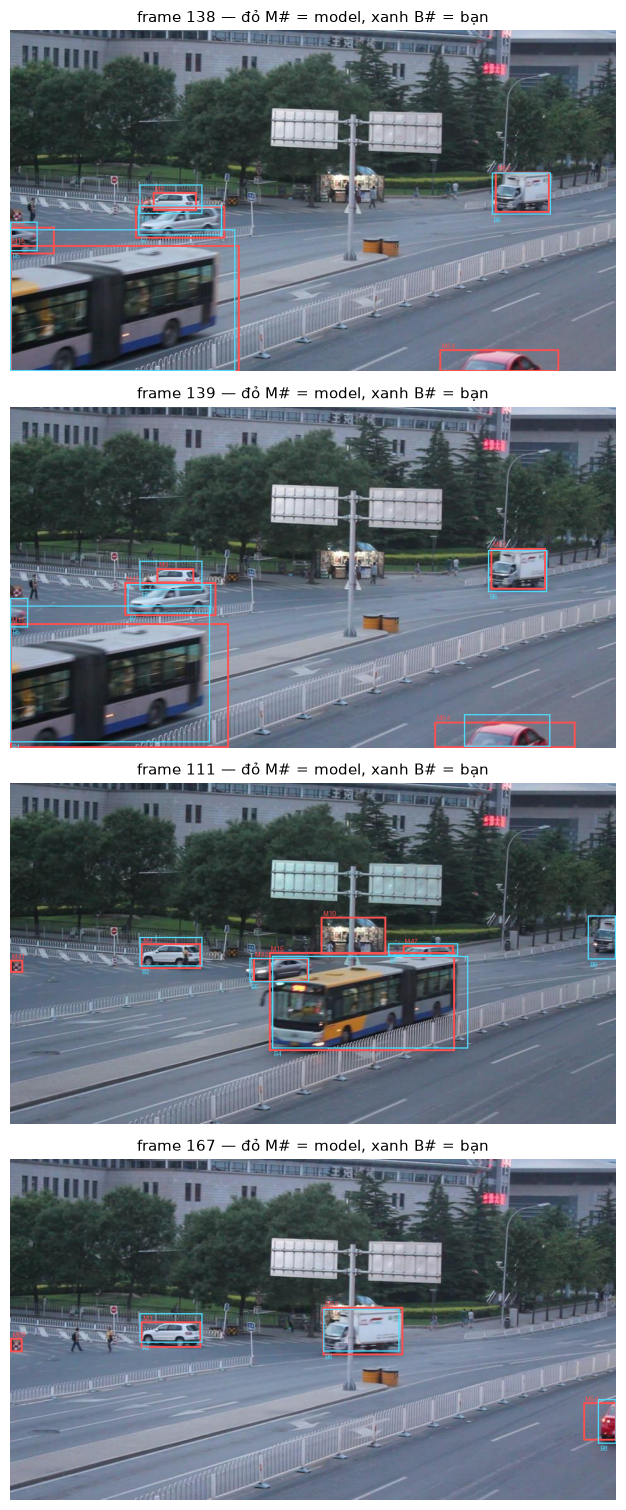

In [11]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

def draw(frame_index, a_dets, b_dets, a_colour=(255, 80, 80), b_colour=(80, 220, 255)):
    image = Image.open(CLIP / "img1" / "{:06d}.jpg".format(frame_index)).convert("RGB")
    canvas = ImageDraw.Draw(image)
    for det in by_frame(a_dets).get(frame_index, []):
        canvas.rectangle((det.x, det.y, det.x + det.w, det.y + det.h), outline=a_colour, width=3)
        canvas.text((det.x + 3, max(0, det.y - 12)), "M{}".format(det.track_id), fill=a_colour)
    for det in by_frame(b_dets).get(frame_index, []):
        canvas.rectangle((det.x, det.y, det.x + det.w, det.y + det.h), outline=b_colour, width=2)
        canvas.text((det.x + 3, det.y + det.h + 2), "B{}".format(det.track_id), fill=b_colour)
    return image

if WORST_FRAMES:
    model_dets, my_dets = parse_mot(MODEL_OUT), parse_mot(MY_LABELS)
    fig, axes = plt.subplots(len(WORST_FRAMES), 1, figsize=(13, 7.6 * len(WORST_FRAMES) / 2))
    axes = axes.ravel() if len(WORST_FRAMES) > 1 else [axes]
    for ax, f in zip(axes, WORST_FRAMES):
        ax.imshow(draw(f, model_dets, my_dets))
        ax.set_title("frame {} — đỏ M# = model, xanh B# = bạn".format(f), fontsize=11)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 6. Thử đổi tham số

Một thí nghiệm nhỏ để thấy detector và tracker ảnh hưởng khác nhau thế nào. Hạ `conf` thì
detector bắt được nhiều xe hơn (**DetA** tăng) nhưng cũng đẻ thêm bbox rác (**FP** tăng).
Đổi tracker thì chủ yếu đổi **AssA**, gần như không đổi DetA.

Chạy cell này nếu còn thời gian; không bắt buộc, nhưng một dòng nhận xét về nó làm báo cáo
của bạn khác hẳn.


In [12]:
RUN_EXPERIMENT = False   # đổi thành True nếu còn thời gian

if RUN_EXPERIMENT and HAS_GOLD:
    from motlib import hota, identity, clear_mot
    gold_dets = parse_mot(GOLD)
    print("{:<28}{:>7}{:>7}{:>7}{:>7}{:>6}{:>6}{:>6}".format(
        "cấu hình", "HOTA", "DetA", "AssA", "IDF1", "FP", "FN", "IDSW"))
    for tracker_name in ("bytetrack.yaml", "botsort.yaml"):
        for conf_value in (0.15, 0.25, 0.40):
            rows_ = run_tracker.track_clip(
                clip=CLIP, model_name=MODEL, tracker=tracker_name, conf=conf_value,
                iou=0.7, imgsz=960, classes=[2, 5, 7], device=DEVICE, verbose=False)
            tmp = OUT / "tmp_{}_{}.txt".format(tracker_name.split(".")[0], conf_value)
            run_tracker.write_mot(rows_, tmp)
            p = parse_mot(tmp)
            h, i, c = hota(gold_dets, p), identity(gold_dets, p), clear_mot(gold_dets, p)
            label = "{} conf={}".format(tracker_name.split(".")[0], conf_value)
            print("{:<28}{:>7.3f}{:>7.3f}{:>7.3f}{:>7.3f}{:>6d}{:>6d}{:>6d}".format(
                label, h["HOTA"], h["DetA"], h["AssA"], i["IDF1"], c["FP"], c["FN"], c["IDSW"]))
else:
    print("Bỏ qua thí nghiệm (RUN_EXPERIMENT=False hoặc chưa có gold).")


Bỏ qua thí nghiệm (RUN_EXPERIMENT=False hoặc chưa có gold).


## 7. Câu hỏi phải trả lời trong báo cáo

Chép bảng tổng hợp ở mục 4 vào `reports/REPORT.md`, rồi trả lời:

1. **MOTA của bạn cao hơn hay thấp hơn IDF1?** Nếu MOTA cao mà IDF1 thấp, nhãn của bạn sai ở
   ID chứ không phải ở chỗ bỏ sót. Vì sao MOTA lại không phạt nặng lỗi đó?
2. **DetA và AssA của model lệch nhau bao nhiêu?** Cái nào kéo HOTA xuống — model *không tìm
   ra xe*, hay *tìm ra rồi nhưng đánh mất ID*?
3. Tìm **một chỗ bạn đúng và model sai**, và **một chỗ model đúng và bạn sai**. Ghi rõ frame, ID,
   và tại sao.
4. Trong ba loại bất đồng ở mục 5, loại nào nhiều nhất? Nó nói gì về clip này (nhiều xe bị
   che? nhiều xe nhỏ ở rìa? nhiều xe cắt nhau?).
5. Nếu phải gán thêm 10 clip nữa, bạn sẽ **sửa gì trong `GUIDELINE_MINI.md`** để người gán
   tiếp theo không mắc lại lỗi bạn vừa mắc?

Đừng quên commit `outputs/*.json` và `outputs/model_clip_01.txt` cùng báo cáo.
